# Master's Project EDA

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("Sales Transaction v.4a.csv", encoding="ISO-8859-1")

df.shape
df.head()
df.info()
df.describe(include="all")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionNo  536350 non-null  object 
 1   Date           536350 non-null  object 
 2   ProductNo      536350 non-null  object 
 3   ProductName    536350 non-null  object 
 4   Price          536350 non-null  float64
 5   Quantity       536350 non-null  int64  
 6   CustomerNo     536295 non-null  float64
 7   Country        536350 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.7+ MB


,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
count,536350,536350,536350,536350,536350.000000,536350.000000,536295.000000,536350
unique,23204,305,3768,3768,NaN,NaN,NaN,38
top,573585,12/5/2019,85123A,Cream Hanging Heart T-Light Holder,NaN,NaN,NaN,United Kingdom
freq,1111,5299,2378,2378,NaN,NaN,NaN,485095
mean,NaN,NaN,NaN,NaN,12.662182,9.919347,15227.893178,NaN
std,NaN,NaN,NaN,NaN,8.490450,216.662300,1716.582932,NaN
min,NaN,NaN,NaN,NaN,5.130000,-80995.000000,12004.000000,NaN
25%,NaN,NaN,NaN,NaN,10.990000,1.000000,13807.000000,NaN
50%,NaN,NaN,NaN,NaN,11.940000,3.000000,15152.000000,NaN
75%,NaN,NaN,NaN,NaN,14.090000,10.000000,16729.000000,NaN


In [2]:
df.isnull().sum()

,0
TransactionNo,0
Date,0
ProductNo,0
ProductName,0
Price,0
Quantity,0
CustomerNo,55
Country,0


# Dataset Feasibility Review

The dataset consists of 536,350 transaction-level records with 8 attributes, providing a large and detailed view of an online retail business over approximately one year. The size of the dataset is sufficient to support robust statistical analysis and pattern discovery without concerns of small-sample bias.


All core transactional fields like TransactionNo, Date, ProductNo, ProductName, Price, Quantity, and Country, are fully populated, indicating strong structural completeness for transaction and product-level analysis.

The CustomerNo field contains a small number of missing values (55 records), which is negligible at the dataset scale but relevant for customer-centric analysis.

The dataset captures:

23,204 unique transactions (A transaction has multiple products, hence the large amount of rows.)

3,768 unique products

38 customer countries

305 distinct transaction dates


In [3]:
df.head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom


In [4]:
df['ProductName'].value_counts()[:10]

,count
ProductName,
Cream Hanging Heart T-Light Holder,2378
Regency Cakestand 3 Tier,2200
Jumbo Bag Red Retrospot,2159
Party Bunting,1727
Lunch Bag Red Retrospot,1639
Assorted Colour Bird Ornament,1501
Popcorn Holder,1476
Set Of 3 Cake Tins Pantry Design,1473
Pack Of 72 Retrospot Cake Cases,1385


### Digging into one product

In [5]:
product_name = "Cream Hanging Heart T-Light Holder"

product_df = df[df["ProductName"] == product_name].copy()

product_df.head()
product_df.shape


(2378, 8)

In [6]:
product_sales = product_df[product_df["Quantity"] > 0]
product_sales["Revenue"] = product_sales["Price"] * product_sales["Quantity"]

/tmp/ipython-input-3607397502.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  product_sales["Revenue"] = product_sales["Price"] * product_sales["Quantity"]


In [7]:
total_units = product_sales["Quantity"].sum()
total_units

np.int64(37956)

In [8]:
total_revenue = product_sales["Revenue"].sum()
total_revenue

np.float64(484592.68999999994)

In [9]:
unique_customers = product_sales["CustomerNo"].nunique()
unique_customers

1103

# Ethics and Bias Considerations

Geographic Bias:
The majority of transactions originate from the United Kingdom. Results may not generalize to global e-commerce markets.

Customer Representation Bias:
Dataset mixes individual consumers and bulk purchasers. High-quantity outliers suggest business/reseller customers. This may skew average spending metrics.


Ethical Considerations:
No PII is present in the dataset. There are also no demographic factors such as gender, age, race, etc present in the dataset so all conclusions can be made without any inbalance in distribution.

# Data Cleaning & Preprocessing Summary

1. Date Conversion: Converted Date from object to pd datetime format to enable time series analysis. This also allows us to access the data in monthly, yearly, daily and hourly format.

2. Missing Customer IDs: Removed rows with missing CustomerNo for customer-level analysis. Since there were only 55 missing values, which is negligible compared to the total size of the dataset, removing them will not affect the size of the dataset.

3. Cancellation Handling: Created IsCancelled flag using Negative Quantity TransactionNo starting with “C”. Separated cancelled transactions from completed sales.

# Key Plots & Statistical Summaries

/tmp/ipython-input-2840468321.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  product_sales["Date"] = pd.to_datetime(product_sales["Date"])


<Axes: title={'center': 'Monthly Revenue for Cream Hanging Heart T-Light Holder'}, xlabel='Date'>

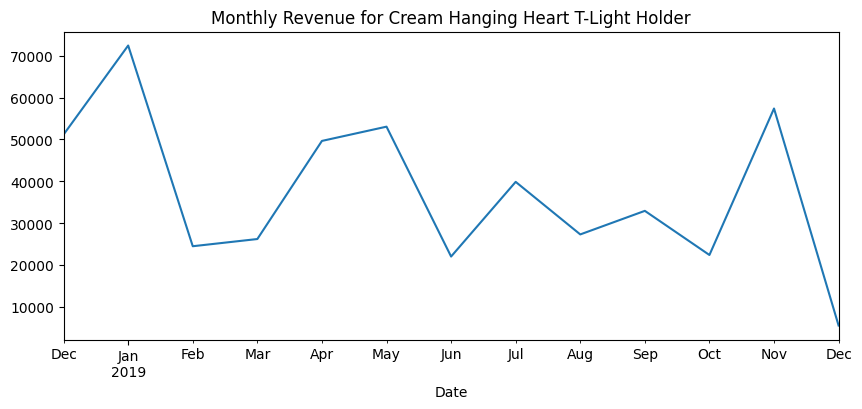

In [10]:
product_sales["Date"] = pd.to_datetime(product_sales["Date"])

monthly_trend = product_sales.groupby(
    product_sales["Date"].dt.to_period("M")
)["Revenue"].sum()

monthly_trend.plot(figsize=(10,4), title=f"Monthly Revenue for {product_name}")

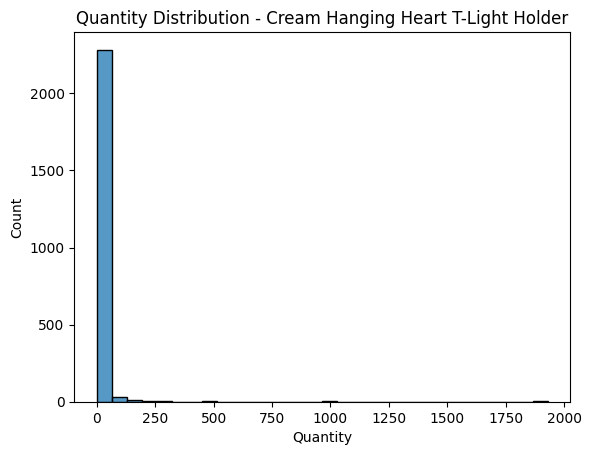

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(product_sales["Quantity"], bins=30)
plt.title(f"Quantity Distribution - {product_name}")
plt.show()

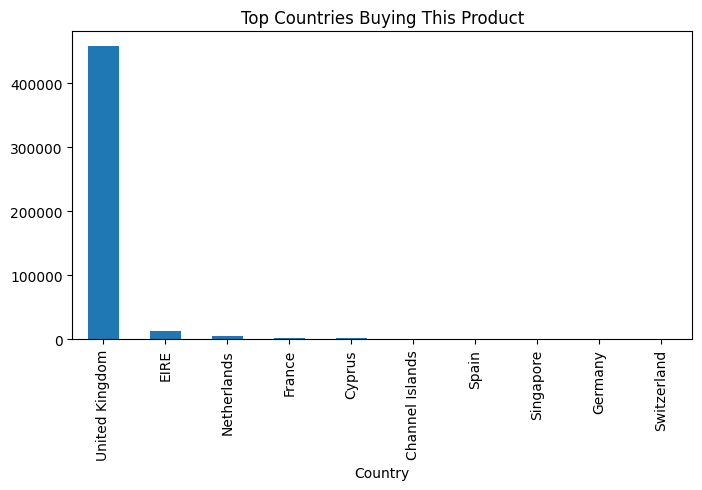

In [12]:
country_sales = product_sales.groupby("Country")["Revenue"].sum().sort_values(ascending=False)

country_sales.head(10).plot(kind="bar", figsize=(8,4))
plt.title("Top Countries Buying This Product")
plt.show()


In [13]:
df = df.dropna(subset=["CustomerNo"])

In [14]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Hour"] = df["Date"].dt.hour

In [15]:
df['TransactionNo'].unique()

array(['581482', '581475', '581476', ..., 'C536506', 'C536543', 'C536548'],
      dtype=object)

From the datacard on Kaggle, it was given that transactions starting with a 'C' mean cancelled transactions.

In [16]:
df["IsCancelled"] = df["TransactionNo"].str.startswith("C")
df.head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Year,Month,Hour,IsCancelled
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom,2019,12,0,False
1,581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom,2019,12,0,False
2,581475,2019-12-09,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom,2019,12,0,False
3,581475,2019-12-09,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom,2019,12,0,False
4,581475,2019-12-09,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom,2019,12,0,False


In [17]:
sales_df = df[~df["IsCancelled"] & (df["Quantity"] > 0)]
sales_df["Revenue"] = sales_df["Price"] * sales_df["Quantity"]

/tmp/ipython-input-1350462146.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales_df["Revenue"] = sales_df["Price"] * sales_df["Quantity"]


In [18]:
sales_df.head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Year,Month,Hour,IsCancelled,Revenue
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom,2019,12,0,False,257.64
1,581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom,2019,12,0,False,383.40
2,581475,2019-12-09,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom,2019,12,0,False,138.36
3,581475,2019-12-09,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom,2019,12,0,False,127.80
4,581475,2019-12-09,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom,2019,12,0,False,71.64


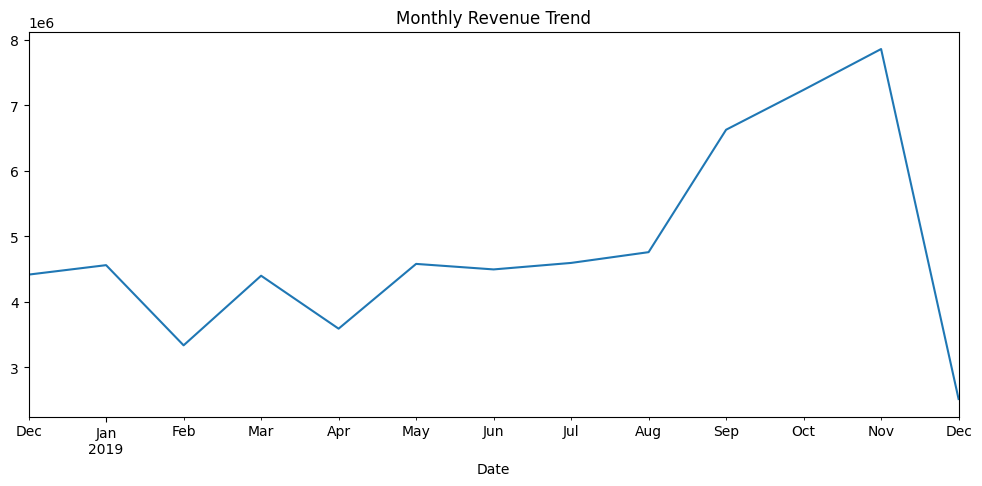

In [19]:
monthly_sales = sales_df.groupby(
    sales_df["Date"].dt.to_period("M")
)["Revenue"].sum()

monthly_sales.plot(figsize=(12,5), title="Monthly Revenue Trend")
plt.show()


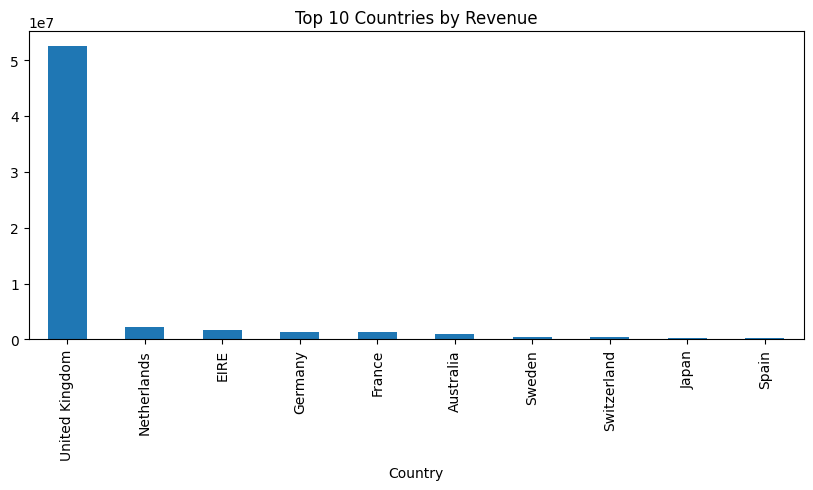

In [20]:
country_sales = sales_df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)

country_sales.head(10)
country_sales.head(10).plot(kind="bar", figsize=(10,4))
plt.title("Top 10 Countries by Revenue")
plt.show()

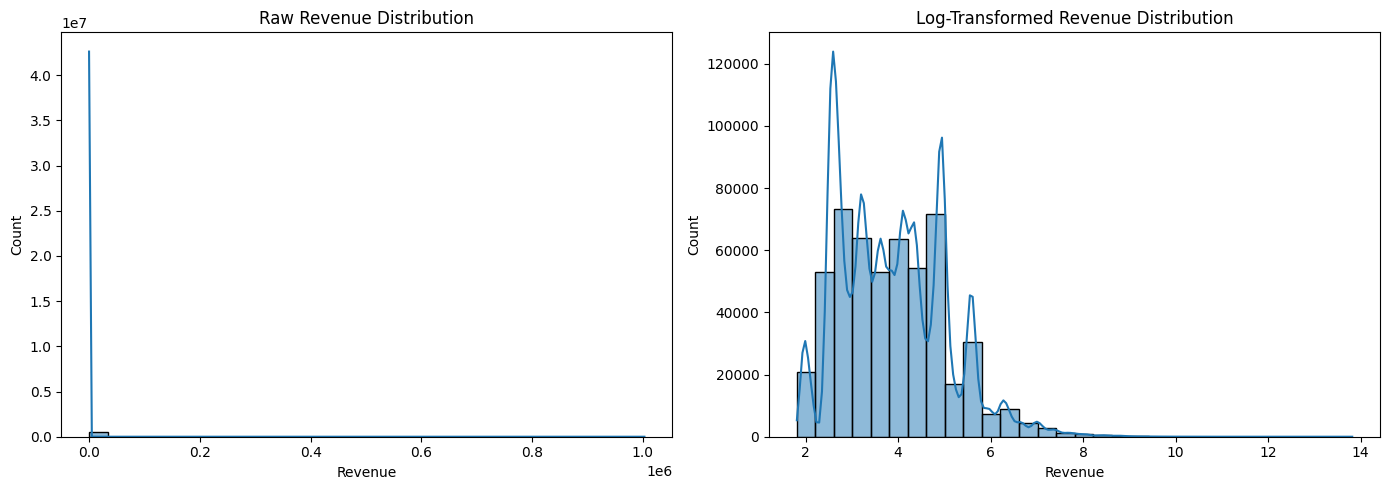

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(sales_df['Revenue'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Raw Revenue Distribution')

sns.histplot(np.log1p(sales_df['Revenue']), bins=30, kde=True, ax=axes[1])
axes[1].set_title('Log-Transformed Revenue Distribution')

plt.tight_layout()
plt.show()


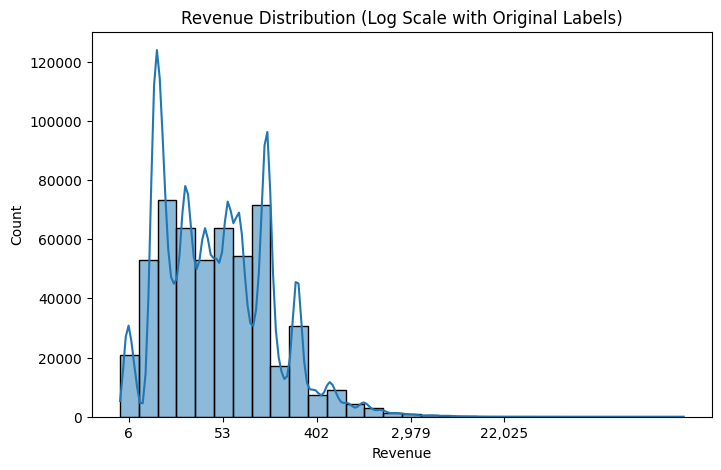

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

log_revenue = np.log1p(sales_df['Revenue'])

plt.figure(figsize=(8,5))
sns.histplot(log_revenue, bins=30, kde=True)

tick_values = [2, 4, 6, 8, 10]

tick_labels = [f"{int(np.expm1(x)):,}" for x in tick_values]

plt.xticks(tick_values, tick_labels)

plt.xlabel("Revenue")
plt.ylabel("Count")
plt.title("Revenue Distribution (Log Scale with Original Labels)")

plt.show()


In [23]:
customer_summary = sales_df.groupby("CustomerNo").agg({
    "TransactionNo": "nunique",
    "Quantity": "sum",
    "Revenue": "sum"
})
customer_summary.describe()


,TransactionNo,Quantity,Revenue
count,4718.000000,4718.000000,4.718000e+03
mean,4.194362,1185.139890,1.334589e+04
std,7.396101,4863.272457,5.439743e+04
min,1.000000,1.000000,5.970000e+00
25%,1.000000,158.000000,1.838447e+03
50%,2.000000,413.000000,4.828470e+03
75%,5.000000,1041.750000,1.190628e+04
max,207.000000,197420.000000,2.112282e+06


In [24]:
sales_df[["Price", "Quantity", "Revenue"]].corr()

,Price,Quantity,Revenue
Price,1.000000,-0.011658,-0.000629
Quantity,-0.011658,1.000000,0.996574
Revenue,-0.000629,0.996574,1.000000


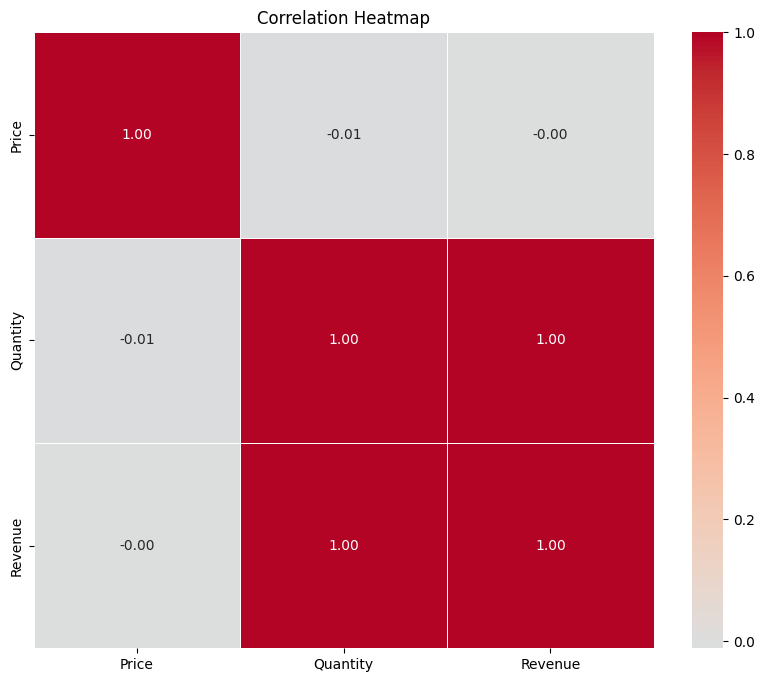

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = sales_df[["Price", "Quantity", "Revenue"]]

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()


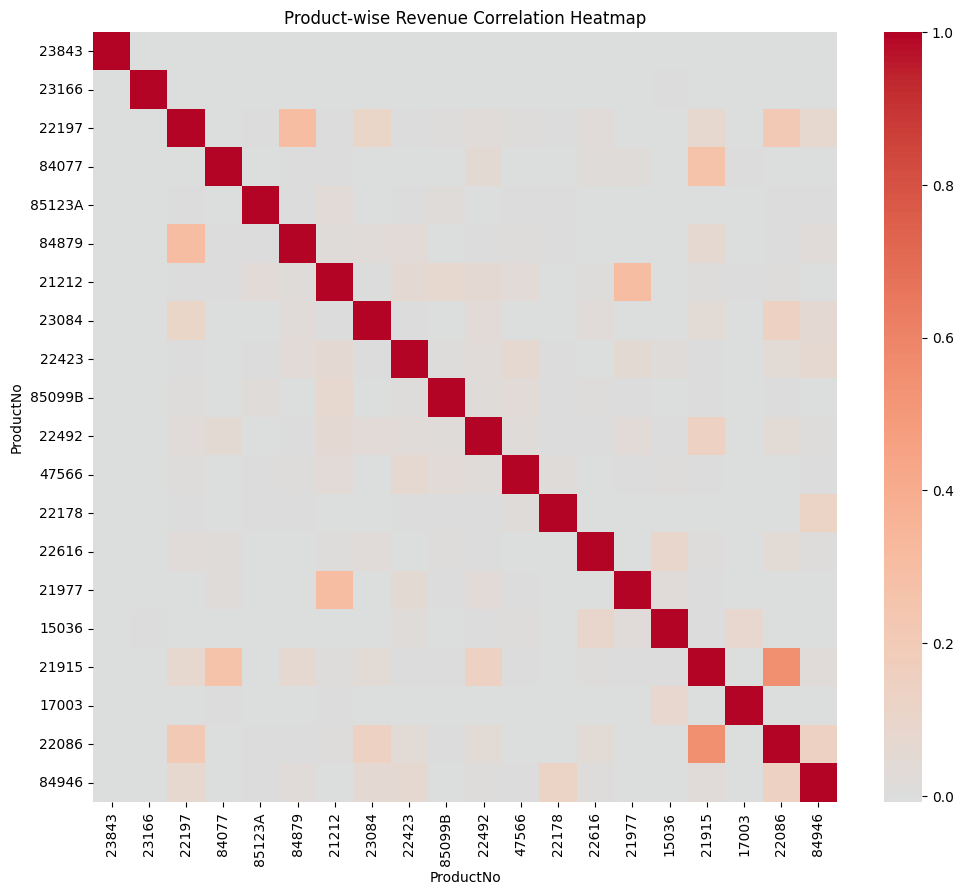

In [26]:
import pandas as pd

product_matrix = sales_df.pivot_table(
    index='TransactionNo',
    columns='ProductNo',
    values='Revenue',
    aggfunc='sum',
    fill_value=0
)

top_products = sales_df.groupby('ProductNo')['Revenue'].sum().nlargest(20).index

filtered_matrix = product_matrix[top_products]

product_corr = filtered_matrix.corr()


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(12,10))
sns.heatmap(
    product_corr,
    cmap="coolwarm",
    center=0
)

plt.title("Product-wise Revenue Correlation Heatmap")
plt.show()


# Insights

1. Sales distribution is highly skewed, indicating presence of bulk buyers.
2. Revenue appears concentrated among a small subset of customers.
3. UK dominates transactions, limiting geographic diversity. Majority of revenue comes from UK.

# Data Limitations

1. Heavy class imbalance between UK and other countries.
2. No demographic data limits fairness analysis.
3. Extreme outliers in Quantity may distort mean-based metrics.
4. No cost/profit information is given, so only revenue analysis is possible.
5. Cancellation reasons are not explicitly recorded.

# Implications for Method Selection

The exploratory data analysis reveals several characteristics that directly influence the choice of forecasting methods.

1. Presence of Seasonality:
The monthly revenue trend shows a clear spike in Q4, suggesting strong seasonal effects. This indicates that models capable of explicitly capturing seasonality are appropriate.

Prophet is well-suited because it decomposes time series into trend and seasonal components and is designed for business data with recurring patterns.

Simple models that ignore seasonality may underperform during peak months.

2. Non-Linear Trend Behavior:
Revenue does not follow a strictly linear pattern. Instead, it shows gradual fluctuations followed by sharp increases, indicating non-linear dynamics.

LSTM is appropriate for capturing complex, non-linear temporal dependencies.

However, its effectiveness depends on having sufficient time points (e.g., daily aggregation rather than monthly).

Since there are limited monthly points, LSTM may not have sufficient data to identify patterns, but Prophet should do much better compared to the baseline.

# Expanding the dataset
Since the data in the dataset is only for one year, we are expanding it by generating data for 5 more years by adding random noise to the existing data and offsetting the dates.
We also add a 3% year on year growth in revenue.

In [27]:
import numpy as np
import pandas as pd

df = sales_df.sort_values("Date").reset_index(drop=True)

years_to_generate = 5
all_years = []

for i in range(years_to_generate):
    temp = df.copy()

    temp["Date"] = temp["Date"] + pd.DateOffset(years=i)

    noise = np.random.normal(1, 0.05, size=len(temp))
    temp["Revenue"] = temp["Revenue"] * noise

    temp["Revenue"] *= (1.03 ** i)

    all_years.append(temp)

expanded_df = pd.concat(all_years).reset_index(drop=True)


In [28]:
expanded_df.head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Year,Month,Hour,IsCancelled,Revenue
0,536597,2018-12-01,22220,Cake Stand Lovebird 2 Tier White,20.45,1,18011.0,United Kingdom,2018,12,0,False,20.241451
1,536522,2018-12-01,21122,Set/10 Pink Polkadot Party Candles,11.53,1,15012.0,United Kingdom,2018,12,0,False,12.377573
2,536522,2018-12-01,22632,Hand Warmer Red Retrospot,12.40,1,15012.0,United Kingdom,2018,12,0,False,14.052904
3,536522,2018-12-01,21664,Ridged Glass Storage Jar Cream Lid,14.09,1,15012.0,United Kingdom,2018,12,0,False,14.390630
4,536522,2018-12-01,22566,Feltcraft Hairband Pink And Purple,11.12,1,15012.0,United Kingdom,2018,12,0,False,12.094723


In [29]:
expanded_df.describe()

,Date,Price,Quantity,CustomerNo,Year,Month,Hour,Revenue
count,2638820,2.638820e+06,2.638820e+06,2.638820e+06,2.638820e+06,2.638820e+06,2638820.0,2.638820e+06
mean,2021-07-04 00:15:00.926322944,1.262964e+01,1.059468e+01,1.523163e+04,2.018922e+03,7.562318e+00,0.0,1.267196e+02
min,2018-12-01 00:00:00,5.130000e+00,1.000000e+00,1.200400e+04,2.018000e+03,1.000000e+00,0.0,4.649458e+00
25%,2020-03-28 00:00:00,1.099000e+01,1.000000e+00,1.381300e+04,2.019000e+03,5.000000e+00,0.0,1.811699e+01
50%,2021-07-20 00:00:00,1.194000e+01,3.000000e+00,1.515900e+04,2.019000e+03,8.000000e+00,0.0,4.638002e+01
75%,2022-10-19 00:00:00,1.409000e+01,1.100000e+01,1.672900e+04,2.019000e+03,1.100000e+01,0.0,1.256300e+02
max,2023-12-09 00:00:00,6.606200e+02,8.099500e+04,1.828700e+04,2.019000e+03,1.200000e+01,0.0,1.171319e+06
std,NaN,7.933218e+00,1.567867e+02,1.716521e+03,2.689198e-01,3.509036e+00,0.0,1.977183e+03


# New Data Structure

In [32]:
df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 527764 entries, 0 to 527763
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   TransactionNo  527764 non-null  object        
 1   Date           527764 non-null  datetime64[ns]
 2   ProductNo      527764 non-null  object        
 3   ProductName    527764 non-null  object        
 4   Price          527764 non-null  float64       
 5   Quantity       527764 non-null  int64         
 6   CustomerNo     527764 non-null  float64       
 7   Country        527764 non-null  object        
 8   Year           527764 non-null  int32         
 9   Month          527764 non-null  int32         
 10  Hour           527764 non-null  int32         
 11  IsCancelled    527764 non-null  bool          
 12  Revenue        527764 non-null  float64       
dtypes: bool(1), datetime64[ns](1), float64(3), int32(3), int64(1), object(4)
memory usage: 42.8+ MB


,Date,Price,Quantity,CustomerNo,Year,Month,Hour,Revenue
count,527764,527764.000000,527764.000000,527764.000000,527764.000000,527764.000000,527764.0,5.277640e+05
mean,2019-07-04 05:58:58.445214464,12.629640,10.594679,15231.626733,2018.921524,7.562318,0.0,1.193069e+02
min,2018-12-01 00:00:00,5.130000,1.000000,12004.000000,2018.000000,1.000000,0.0,5.130000e+00
25%,2019-03-28 00:00:00,10.990000,1.000000,13813.000000,2019.000000,5.000000,0.0,1.717000e+01
50%,2019-07-20 00:00:00,11.940000,3.000000,15159.000000,2019.000000,8.000000,0.0,4.383000e+01
75%,2019-10-19 00:00:00,14.090000,11.000000,16729.000000,2019.000000,11.000000,0.0,1.194000e+02
max,2019-12-09 00:00:00,660.620000,80995.000000,18287.000000,2019.000000,12.000000,0.0,1.002718e+06
std,NaN,7.933224,156.786795,1716.522182,0.268920,3.509039,0.0,1.851192e+03


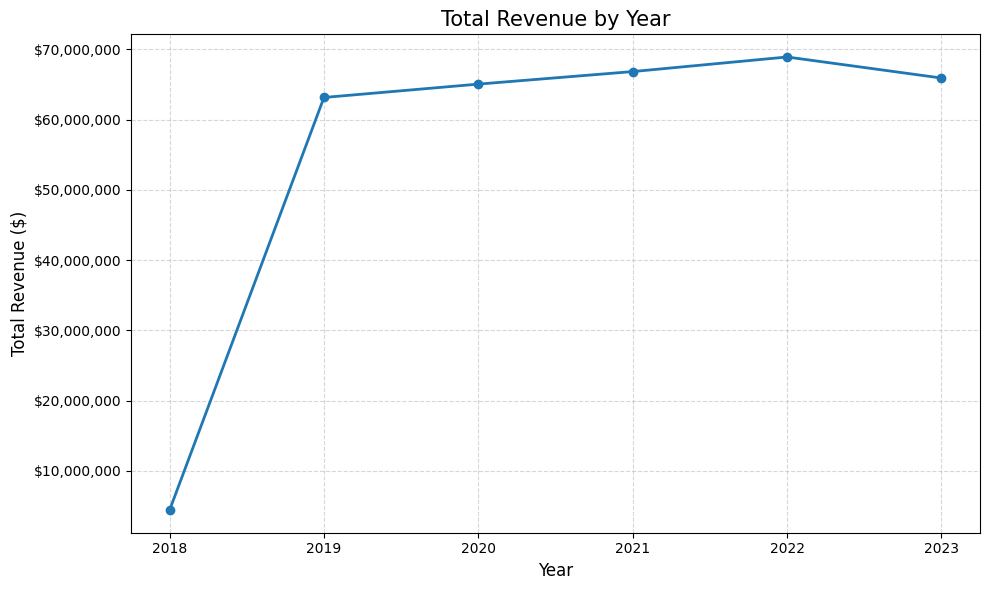

In [46]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

yearly_revenue = (
    expanded_df
    .groupby(expanded_df["Date"].dt.year)["Revenue"]
    .sum()
    .reset_index()
)

yearly_revenue.columns = ["Year", "Total_Revenue"]

plt.figure(figsize=(10,6))

plt.plot(
    yearly_revenue["Year"],
    yearly_revenue["Total_Revenue"],
    marker="o",
    linewidth=2
)

plt.title("Total Revenue by Year", fontsize=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Revenue ($)", fontsize=12)

plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('${x:,.0f}')
)

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


/tmp/ipython-input-2933111268.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M", on="Date")["Revenue"]


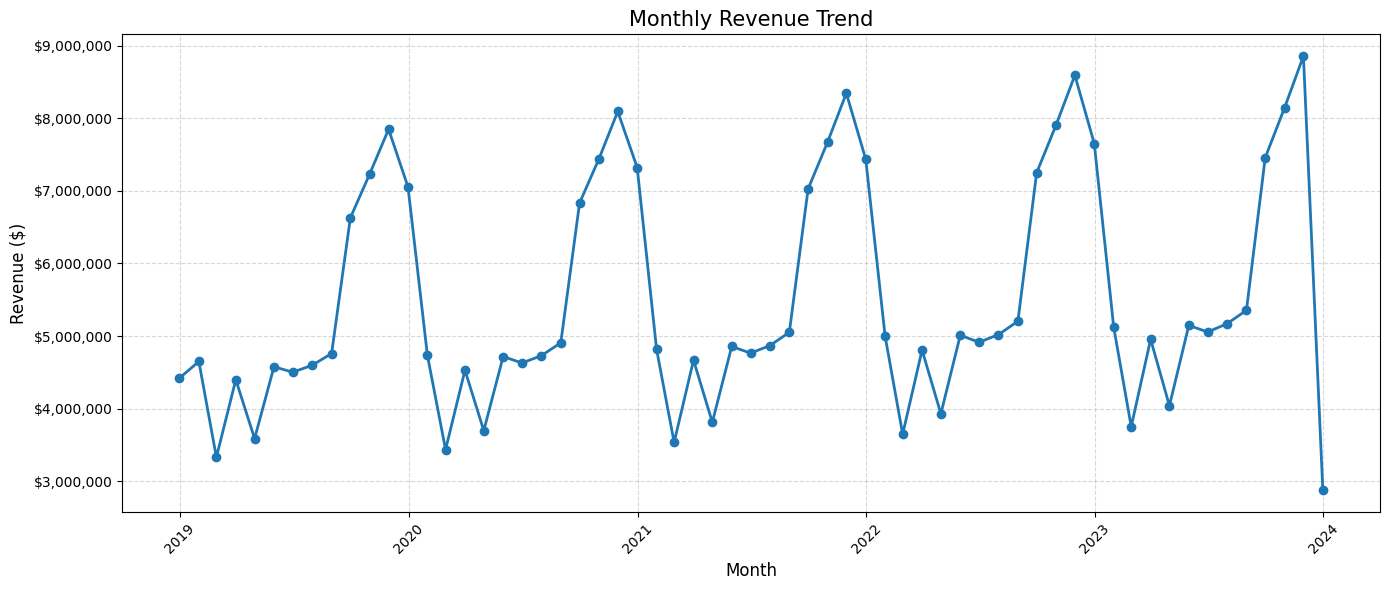

In [45]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

monthly_revenue = (
    expanded_df
    .resample("M", on="Date")["Revenue"]
    .sum()
)

plt.figure(figsize=(14,6))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue Trend", fontsize=15)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Revenue ($)", fontsize=12)

plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('${x:,.0f}')
)

plt.xticks(rotation=45)

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

/tmp/ipython-input-384858984.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M", on="Date")["Revenue"]


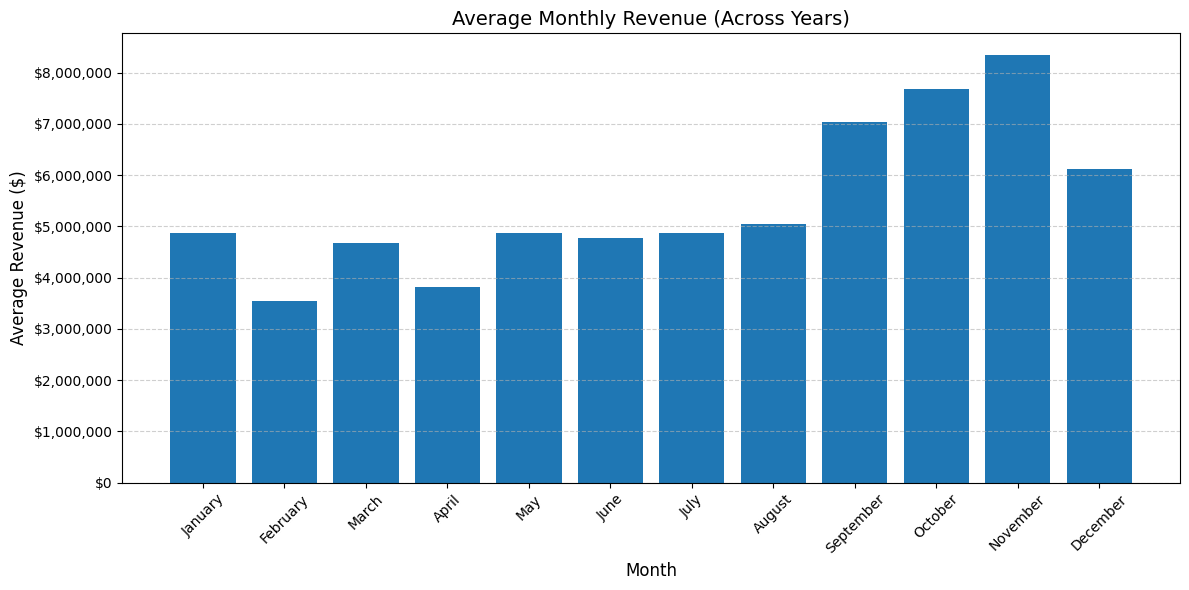

In [44]:
import calendar
import matplotlib.ticker as mtick

monthly_avg = (
    expanded_df
    .resample("M", on="Date")["Revenue"]
    .sum()
    .groupby(lambda x: x.month)
    .mean()
)

monthly_avg.index = [calendar.month_name[i] for i in monthly_avg.index]

plt.figure(figsize=(12,6))

bars = plt.bar(monthly_avg.index, monthly_avg.values)

plt.title("Average Monthly Revenue (Across Years)", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Average Revenue ($)", fontsize=12)

plt.xticks(rotation=45)

# Format y-axis as currency
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


In [48]:
top5_products = (
    expanded_df
    .groupby("ProductName")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

top5_df = expanded_df[expanded_df["ProductName"].isin(top5_products)]


/tmp/ipython-input-321589541.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key="Date", freq="M")


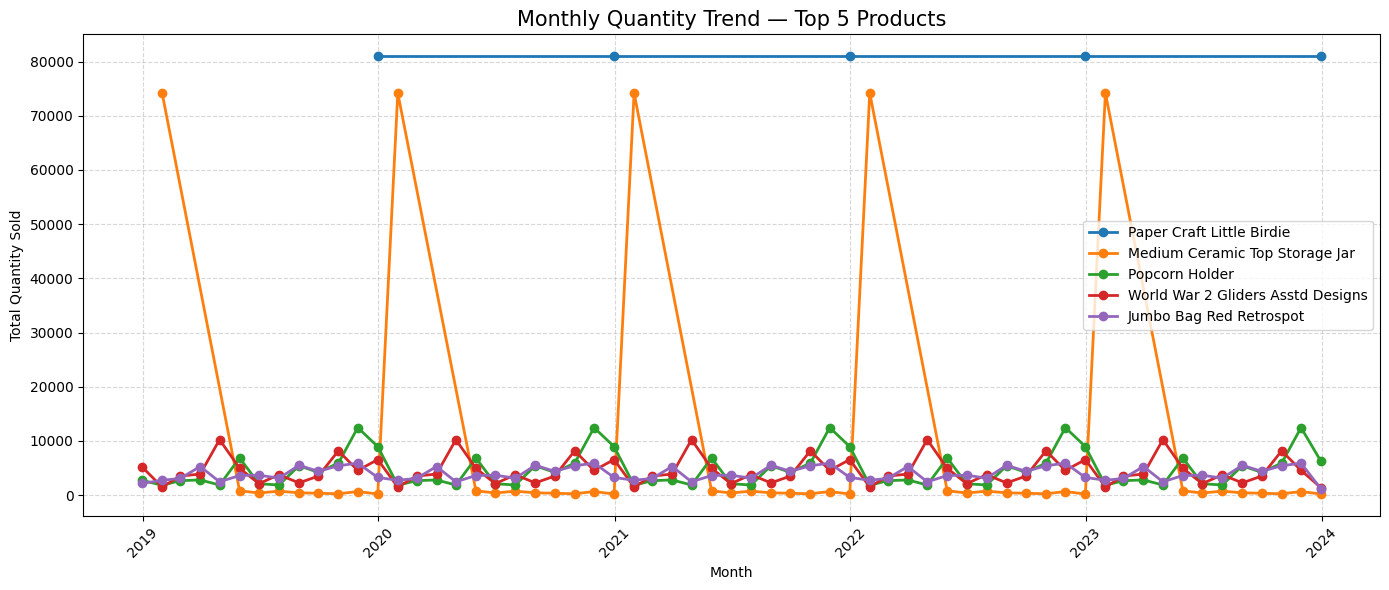

In [49]:
monthly_quantity = (
    top5_df
    .groupby([
        "ProductName",
        pd.Grouper(key="Date", freq="M")
    ])["Quantity"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14,6))

for product in top5_products:
    product_data = monthly_quantity[
        monthly_quantity["ProductName"] == product
    ]

    plt.plot(
        product_data["Date"],
        product_data["Quantity"],
        marker="o",
        linewidth=2,
        label=product
    )

plt.title("Monthly Quantity Trend — Top 5 Products", fontsize=15)
plt.xlabel("Month")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


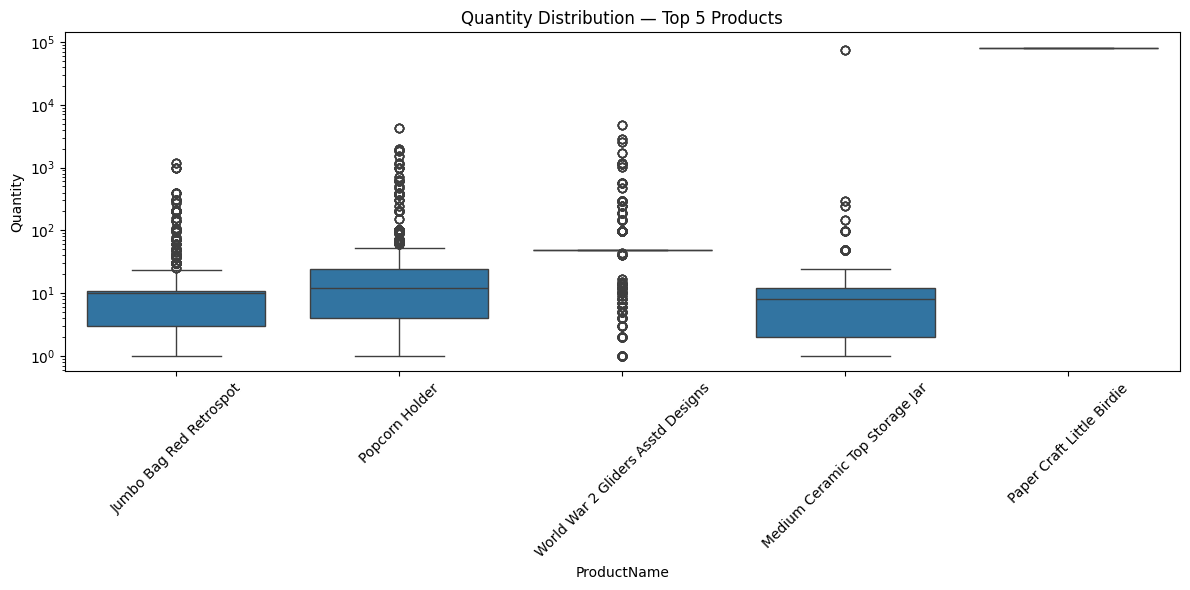

In [52]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=top5_df,
    x="ProductName",
    y="Quantity"
)
plt.yscale("log")

plt.title("Quantity Distribution — Top 5 Products")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [54]:
pc_lb = expanded_df[
    expanded_df["ProductName"] == "Paper Craft Little Birdie"
].copy()


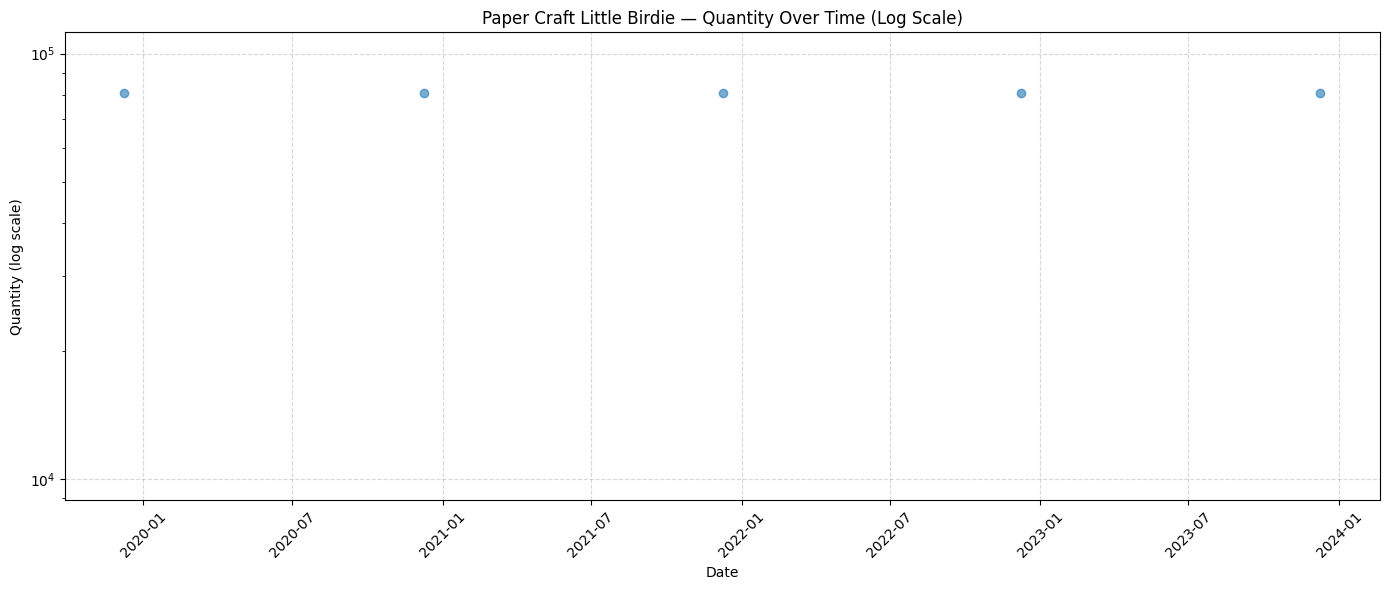

In [55]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(14,6))

plt.scatter(pc_lb["Date"], pc_lb["Quantity"], alpha=0.6)

plt.yscale("log")

plt.title("Paper Craft Little Birdie — Quantity Over Time (Log Scale)")
plt.xlabel("Date")
plt.ylabel("Quantity (log scale)")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


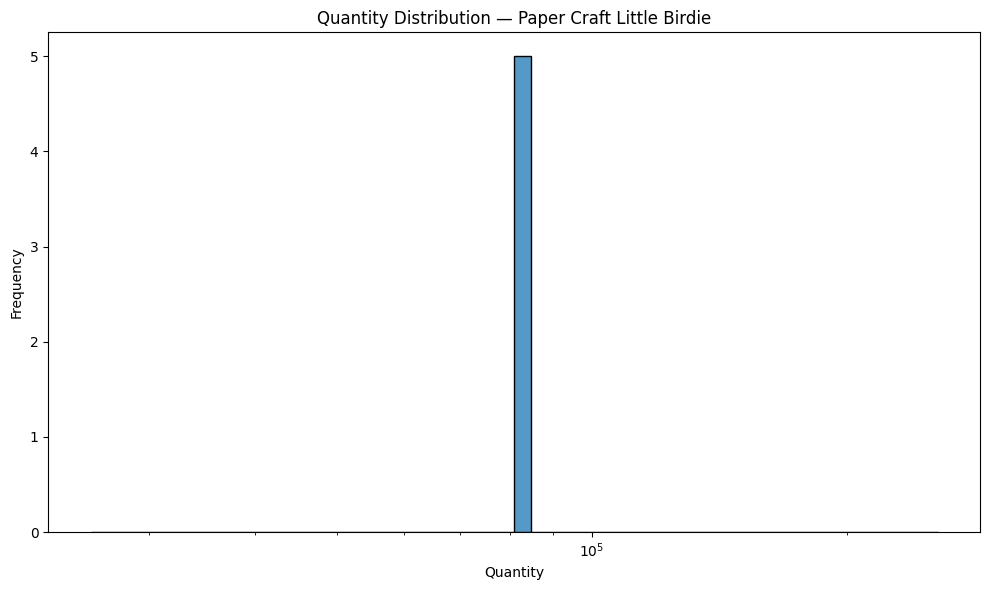

In [56]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(pc_lb["Quantity"], bins=50, log_scale=True)

plt.title("Quantity Distribution — Paper Craft Little Birdie")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [57]:
pc_lb.sort_values("Quantity", ascending=False).head(10)


,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Year,Month,Hour,IsCancelled,Revenue,Outlier
526567,581483,2019-12-09,23843,Paper Craft Little Birdie,12.38,80995,16446.0,United Kingdom,2019,12,0,False,9.995687e+05,True
1054331,581483,2020-12-09,23843,Paper Craft Little Birdie,12.38,80995,16446.0,United Kingdom,2019,12,0,False,1.074182e+06,True
1582095,581483,2021-12-09,23843,Paper Craft Little Birdie,12.38,80995,16446.0,United Kingdom,2019,12,0,False,1.005792e+06,True
2109859,581483,2022-12-09,23843,Paper Craft Little Birdie,12.38,80995,16446.0,United Kingdom,2019,12,0,False,1.028355e+06,True
2637623,581483,2023-12-09,23843,Paper Craft Little Birdie,12.38,80995,16446.0,United Kingdom,2019,12,0,False,1.171319e+06,True


In [62]:
pc_lb.groupby("CustomerNo")["Quantity"].sum().sort_values(ascending=False).head()


,Quantity
CustomerNo,
16446.0,404975


## The 'Paper Craft Little Birdie' product is only bought by one customer in a bulk quantity periodically, as the data shows. Hence, this product is not suitable for forecasting.

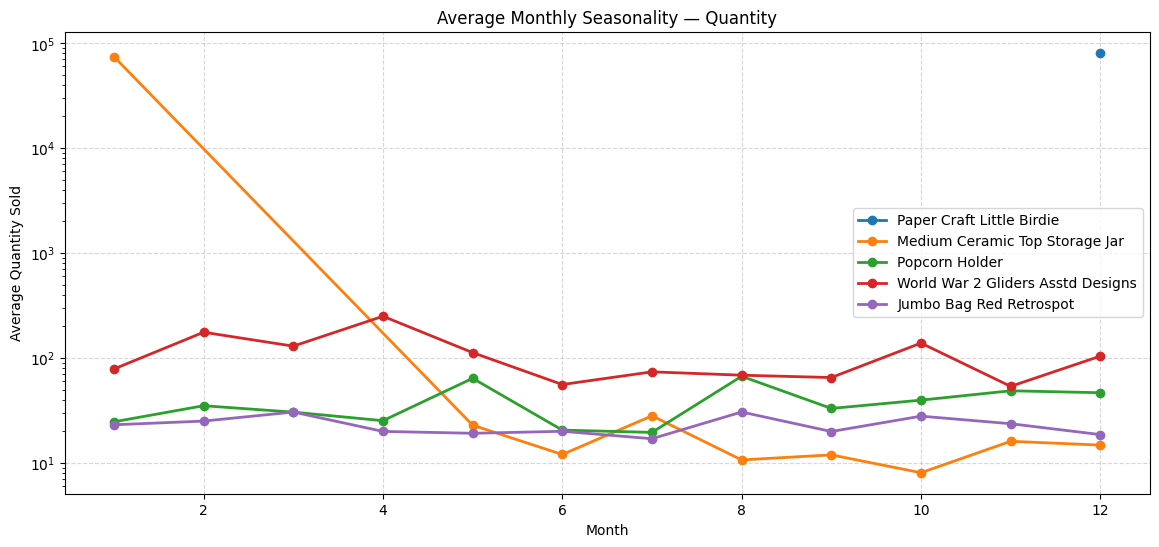

In [63]:
seasonality = (
    top5_df
    .groupby([
        "ProductName",
        top5_df["Date"].dt.month
    ])["Quantity"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14,6))

for product in top5_products:
    product_data = seasonality[
        seasonality["ProductName"] == product
    ]

    plt.plot(
        product_data["Date"],
        product_data["Quantity"],
        marker="o",
        linewidth=2,
        label=product
    )
plt.yscale("log")
plt.title("Average Monthly Seasonality — Quantity")
plt.xlabel("Month")
plt.ylabel("Average Quantity Sold")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


# Conclusions:


## Key Insights

### 1. Wholesale Buyers Exists and cause outliers
- One example - The product **"Paper Craft Little Birdie"** is purchased by only **one customer (ID: 16446)**.
- It is ordered in massive periodic spikes.
- This is not retail demand — it reflects bulk/wholesale behavior.
- Including it would distort quantity distribution and bias forecasting models.

**Conclusion:** The dataset mixes retail and wholesale demand regimes.


### 2. Quantity Distribution is Highly Skewed
- Most products likely have small, frequent purchases.
- A few products show extreme outliers.
- The target variable (Quantity) is right-skewed and heavy-tailed.

**Implication:**  
Log transformations or robust modeling approaches may be required.


### 3. Customer Concentration Risk
- Certain products may be dominated by a small number of customers.
- This increases volatility and reduces generalizability.

**Implication:**  
Customer segmentation or filtering is required before choosing the product to model.


### 4. Demand is Intermittent
- Some products show sparse purchase activity.
- Monthly aggregation may smooth behavior but daily forecasting may be noisy.

**Implication:**  
Model granularity (daily vs monthly) must be chosen carefully.


# Data Limitations

1. No explicit channel flag (Retail vs Wholesale).
2. No promotion/price discount information.
3. No inventory levels (cannot detect stockouts).
4. No product category.
5. No external signals (seasonality drivers, holidays, macro trends).

---

# Assumptions Made

1. Quantity represents actual demand (not stock transfers).
2. Large single-customer spikes are wholesale behavior.
3. Retail behavior is more representative for forecasting.

These assumptions must be validated before production deployment in a real-world scenario.
